# Quickstart

Autor: Luis M. de la Cruz


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import flopy
import os
import xmf6

In [285]:
### ---------- COMPONENTES ----------

# --- Inicialización ---
init = {
    'sim_name' : "quick_start",
#    'exe_name' : "C:\\Users\\luiggi\\Documents\\GitSites\\xmf6\\mf6\\windows\\mf6",
    'exe_name' : "../../mf6/macosarm/mf6",
    'sim_ws' : "output_qs"
}

# --- Discretización temporal - TDIS ---
time = {}

# --- Solución numérica - IMS ---
ims = {}

# --- Modelo de flujo - GWF ---
gwf = { 
    'modelname': init["sim_name"],
    'save_flows': True
}

### ---------- PAQUETES ----------

# --- Discretización espacial - DIS ---
Lx = 10
Ly = 10
nx = 20 # ncol
ny = 20 # nrow
dx = Lx / nx # delr
dy = Ly / ny # delc

dis = {
    'nrow': ny, 
    'ncol': nx,
    'delr': dx,
    'delc': dy,
}

# --- Condiciones iniciales - IC---
ic = {}

# --- Condiciones de frontera - CHD ---
chd = {
    'stress_period_data': [[(0, 0, 0), 1.], 
                           [(0, dis['nrow']-1, dis['ncol']-1), 0.]]
}

# --- Propiedades de flujo - NPF ---
npf = {
    'save_specific_discharge': True,
}

# --- Configuración de la salida - OC ---
oc = {
    'budget_filerecord': f"{init['sim_name']}.bud",
    'head_filerecord': f"{init['sim_name']}.hds",
    'saverecord': [("HEAD", "ALL"), ("BUDGET", "ALL")],
}

### ---------- Inicialización de la simulación ----------
o_sim = xmf6.gwf.initialize(silent = True, init = init, time = time, ims = ims)

### ---------- Inicialización del modelo de flujo GWF ----------
o_gwf = xmf6.gwf.build(o_sim, silent = True, gwf = gwf, dis = dis, ic = ic, chd = chd, npf = npf, oc = oc)

### ---------- Escritura de los archivos de entrada para MODFLOW 6 ----------
o_sim.write_simulation(silent = True)

### ---------- Ejecución de la simulación ----------
o_sim.run_simulation(silent = True)

(True, [])

In [286]:
# --- Recuperamos los resultados de la simulación ---
head = xmf6.gwf.get_head(o_sim, o_gwf)
qx, qy, qz, n_q = xmf6.gwf.get_specific_discharge(o_sim, o_gwf)
grid = o_gwf.modelgrid
x, y, z = grid.xyzcellcenters

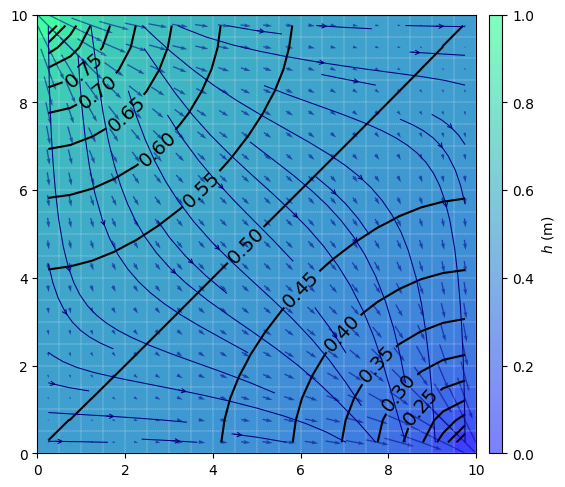

In [287]:
# --- Definición de la figura ---
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.set_aspect('equal')
pmv0 = flopy.plot.PlotMapView(model = o_gwf, ax = ax)
pmv0.plot_grid(colors = 'w', lw = 0.25, ls="--")
cb = pmv0.plot_array(head, cmap = "winter", alpha=0.5)
pmv0.plot_vector(qx, qy, normalize=False, color="darkblue", alpha=0.55)
ct = pmv0.contour_array(head, levels=20, colors='k', linewidths=1.5)
ax.clabel(ct, fontsize=14)
ax.streamplot(x, y[::-1][:], qx[0], qy[0][::-1], color='navy', 
              integration_direction = 'both', 
              density = [0.5, 0.5], linewidth = 0.75, broken_streamlines = True, 
              arrowstyle = "->", arrowsize = 0.75,  )
plt.colorbar(cb, ax = ax, label = "$h$ (m)", 
             cax = xmf6.vis.cax(ax, cb))
plt.show()